# Transmission time delay in a four-region network

This example ships hydrogen from A to three destinations: B, C, and D. The direct links have symmetric travel times, so the delay from A to B is the same as from B to A.

The model uses a closed horizon: no commodity is initially in transit, and a dispatch is only allowed when it can arrive before the final time step. Positive time delays cannot currently be combined with time-series aggregation.

## 1. Import packages

FINE defines the energy system model and its components; pandas is used to create the time series for supply and demand.

In [1]:
import pandas as pd

import fine as fn

The four regions are modeled over four one-hour time steps. The `time_delay` DataFrame is symmetric: its columns are origins and rows are destinations, as for `distances`. Direct shipments from A take one step to B, two to C, and three to D.

In [2]:
regions = ["A", "B", "C", "D"]
shipment_amount = 10

# Columns are origins and rows are destinations, as for distances.
time_delay = pd.DataFrame(
    [[0, 1, 2, 3], [1, 0, 1, 2], [2, 1, 0, 1], [3, 2, 1, 0]],
    index=regions,
    columns=regions,
)
delays_from_a = {destination: time_delay.loc[destination, "A"] for destination in regions[1:]}

esM = fn.EnergySystemModel(
    locations=set(regions),
    commodities={"hydrogen"},
    commodityUnitsDict={"hydrogen": "kg"},
    numberOfTimeSteps=4,
    hoursPerTimeStep=1,
    costUnit="EUR",
    lengthUnit="km",
)

Thirty kilograms are available at A only in time step 0. Ten kilograms are required at each destination after the respective A → destination delay. This creates three visually distinct arrival times.

In [3]:
supply = pd.DataFrame(0, index=range(esM.numberOfTimeSteps), columns=regions)
supply.loc[0, "A"] = shipment_amount * len(delays_from_a)

demand = pd.DataFrame(0, index=range(esM.numberOfTimeSteps), columns=regions)
for destination, delay in delays_from_a.items():
    demand.loc[delay, destination] = shipment_amount

esM.add(
    fn.Source(
        esM=esM,
        name="Hydrogen supply at A",
        commodity="hydrogen",
        hasCapacityVariable=False,
        operationRateMax=supply,
    )
)

esM.add(
    fn.Sink(
        esM=esM,
        name="Hydrogen demand",
        commodity="hydrogen",
        hasCapacityVariable=False,
        operationRateFix=demand,
    )
)

The `timeDelay` DataFrame is passed directly to one transmission component. Only the three links connecting A with B, C, and D are eligible. Each link is eligible in both directions, and because the delay matrix is symmetric, its outward and return travel times are identical.

In [4]:
link_eligibility = pd.DataFrame(0, index=regions, columns=regions)
for destination in regions[1:]:
    link_eligibility.loc[destination, "A"] = 1
    link_eligibility.loc["A", destination] = 1

esM.add(
    fn.Transmission(
        esM=esM,
        name="Hydrogen shipments",
        commodity="hydrogen",
        timeDelay=time_delay,
        hasCapacityVariable=False,
        opexPerOperation=1,
        locationalEligibility=link_eligibility,
    )
)

## 5. Optimize the model

FINE selects an available solver when none is specified. Pass `solver="glpk"`, `solver="highs"`, or another installed solver explicitly if needed.

In [5]:
esM.optimize()

Set parameter Threads to value 3
Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Rocky Linux 9.6 (Blue Onyx)")

CPU model: QEMU Virtual CPU version 2.5+, instruction set [SSE2]
Thread count: 8 physical cores, 8 logical processors, using up to 3 threads

Optimize a model with 28 rows, 40 columns and 64 nonzeros
Model fingerprint: 0x8a264a39
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+03, 2e+03]
  Bounds range     [1e+01, 3e+01]
  RHS range        [0e+00, 0e+00]
Presolve removed 28 rows and 40 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.5700000e+04   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.00 work units)
Optimal objective  6.570000000e+04


The table and chart show each dispatch from A, its delayed arrival, and the corresponding demand. All three shipments leave at time step 0, but they arrive at B, C, and D after one, two, and three steps respectively.

,dispatch A → B,dispatch A → C,dispatch A → D,arrival at B,arrival at C,arrival at D,demand at B,demand at C,demand at D
time step,,,,,,,,,
0,10.0,10.0,10.0,0.0,0.0,0.0,0,0,0
1,0.0,0.0,0.0,10.0,0.0,0.0,10,0,0
2,0.0,0.0,0.0,0.0,10.0,0.0,0,10,0
3,0.0,0.0,0.0,0.0,0.0,10.0,0,0,10


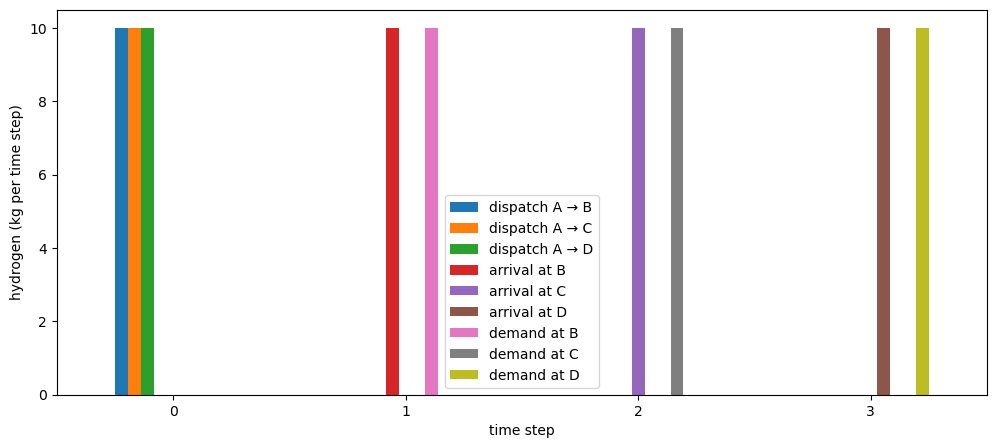

In [6]:
transmission_model = esM.componentModelingDict["TransmissionModel"]
ip_name = esM.investmentPeriodNames[0]
flows = transmission_model.getOptimalValues(
    "operationVariablesOptimum", ip=ip_name
)["values"]

dispatches = pd.DataFrame(
    {
        f"dispatch A → {destination}": flows.loc[[("Hydrogen shipments", "A", destination)]].T.iloc[:, 0]
        for destination in delays_from_a
    }
)
arrivals = pd.DataFrame(
    {
        f"arrival at {destination}": dispatches[f"dispatch A → {destination}"].shift(
            delays_from_a[destination], fill_value=0
        )
        for destination in delays_from_a
    }
)
demands = demand.rename(columns={destination: f"demand at {destination}" for destination in delays_from_a})

timeline = pd.concat([dispatches, arrivals, demands[list(demands.columns[1:])]], axis=1)
timeline.index.name = "time step"
display(timeline)
timeline.plot.bar(rot=0, ylabel="hydrogen (kg per time step)", figsize=(12, 5));

In [7]:
time_delay

,A,B,C,D
A,0,1,2,3
B,1,0,1,2
C,2,1,0,1
D,3,2,1,0


In [8]:
demand

,A,B,C,D
0,0,0,0,0
1,0,10,0,0
2,0,0,10,0
3,0,0,0,10
